In [2]:
import pandas as pd

In [3]:
df=pd.read_csv("/content/drive/MyDrive/revinr/agents_final_clean.csv")

In [4]:
df.head()

,agent_name,agent_url,emails,phones,logo_url,logo_path,source,last_updated,domain
0,International,https://www.gold.ac.uk/international,NaN,NaN,NaN,NaN,https://www.gold.ac.uk/international/represent...,2026-06-02,www.gold.ac.uk
1,International,https://www.gold.ac.uk/international/,NaN,NaN,NaN,NaN,https://www.gold.ac.uk/international/represent...,2026-06-02,www.gold.ac.uk
2,Erasmus and International Exchange,https://www.gold.ac.uk/international-exchange-...,NaN,NaN,NaN,NaN,https://www.gold.ac.uk/international/represent...,2026-06-02,www.gold.ac.uk
3,Agent representation Form,https://www.gold.ac.uk/international/represent...,int-agents@gold.ac.uk,NaN,NaN,NaN,https://www.gold.ac.uk/international/represent...,2026-06-02,www.gold.ac.uk
4,inovaeducation.com/country/chile/,https://www.inovaeducation.com/country/chile/,NaN,NaN,https://www.inovaeducation.com/wp-content/uplo...,logos\a86c999c7b.png,https://www.gold.ac.uk/international/represent...,2026-06-02,www.inovaeducation.com


In [5]:
df["agent_name"] = df["agent_name"].astype(str)
df["domain"] = df["agent_url"].astype(str)

TOP DOMAINS (WHERE AGENTS COME FROM)

<Axes: title={'center': 'Top 10 Agent Domains'}, xlabel='domain'>

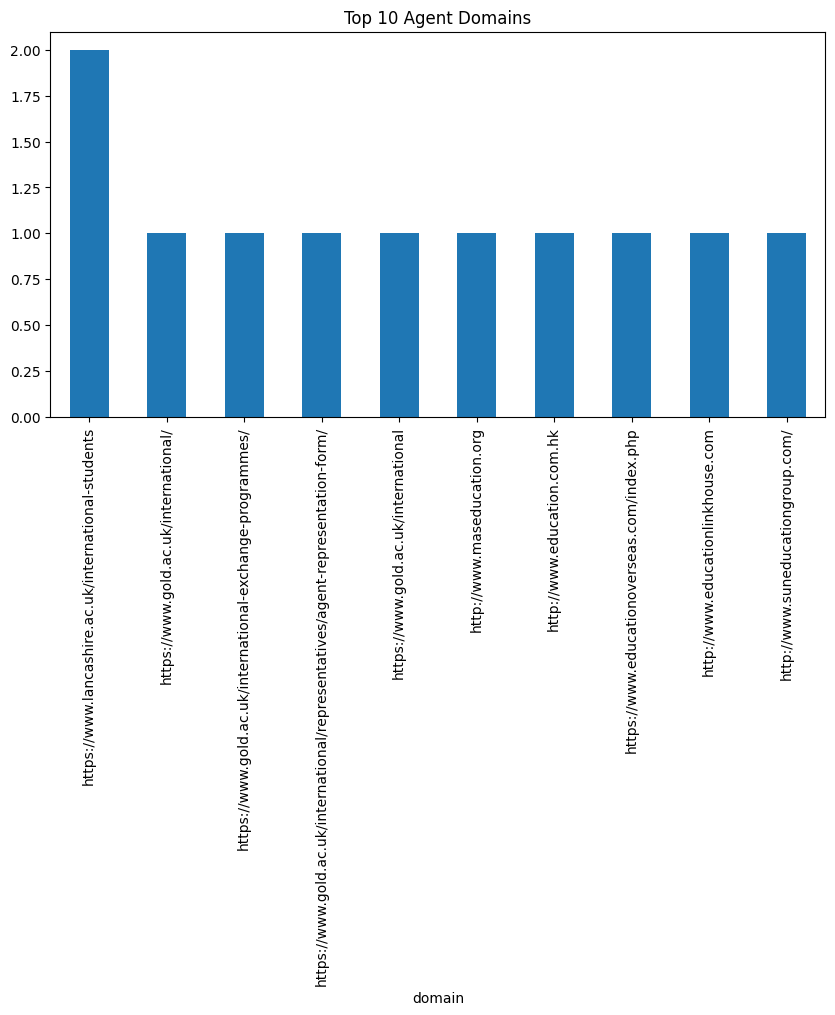

In [6]:
top_domains = df["domain"].value_counts().head(10)

top_domains.plot(kind="bar", figsize=(10,5), title="Top 10 Agent Domains")

TOP DOMAINS (WHERE AGENTS COME FROM)

<Axes: title={'center': 'Agents per University'}, ylabel='source'>

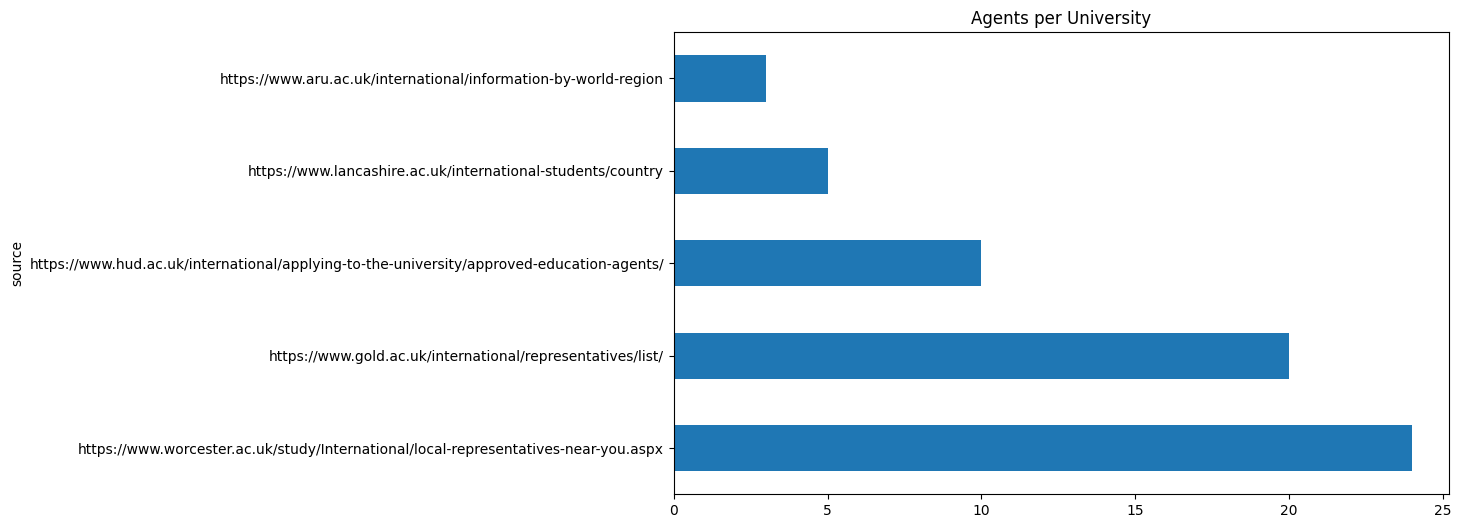

In [7]:
university_agents = df["source"].value_counts()

university_agents.plot(kind="barh", figsize=(10,6), title="Agents per University")

EMAIL COVERAGE (VERY IMPORTANT SLIDE)

<Axes: title={'center': 'Email Availability in Agent Dataset'}, ylabel='count'>

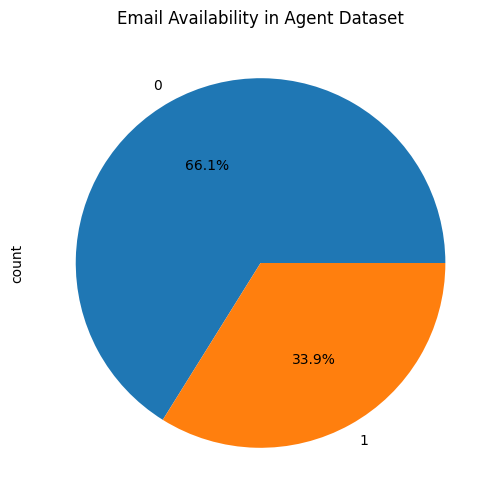

In [8]:
df["has_email"] = df["emails"].fillna("").apply(lambda x: 1 if len(str(x)) > 3 else 0)

email_stats = df["has_email"].value_counts()

email_stats.plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,6),
    title="Email Availability in Agent Dataset"
)

PHONE COVERAGE

<Axes: title={'center': 'Phone Availability in Agent Dataset'}, ylabel='count'>

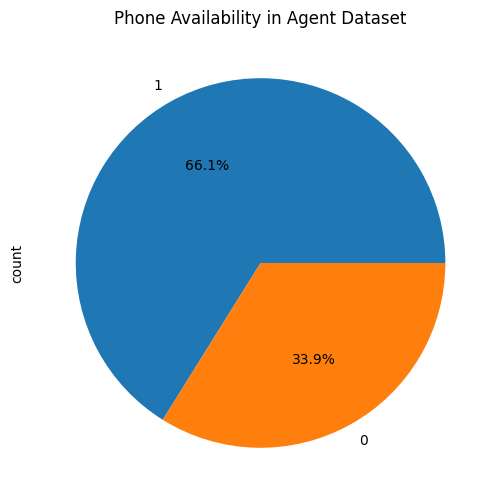

In [9]:
df["has_phone"] = df["phones"].fillna("").apply(lambda x: 1 if len(str(x)) > 3 else 0)

df["has_phone"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,6),
    title="Phone Availability in Agent Dataset"
)

<Axes: title={'center': 'Agent Data Quality Score'}, xlabel='quality_score'>

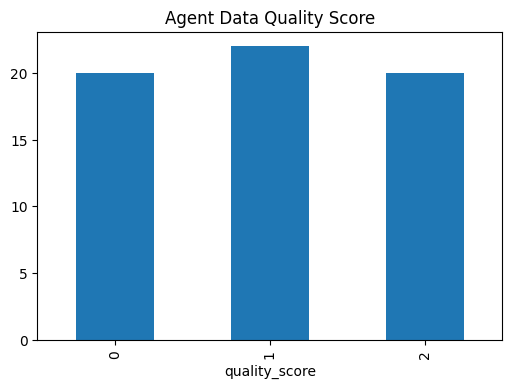

In [11]:
df["quality_score"] = (
    df["emails"].fillna("").apply(lambda x: 1 if len(str(x)) > 3 else 0) +
    df["phones"].fillna("").apply(lambda x: 1 if len(str(x)) > 3 else 0)
)

df["quality_score"].value_counts().sort_index().plot(
    kind="bar",
    figsize=(6,4),
    title="Agent Data Quality Score"
)

<Axes: title={'center': 'Top Repeated Agent Names'}, ylabel='agent_name'>

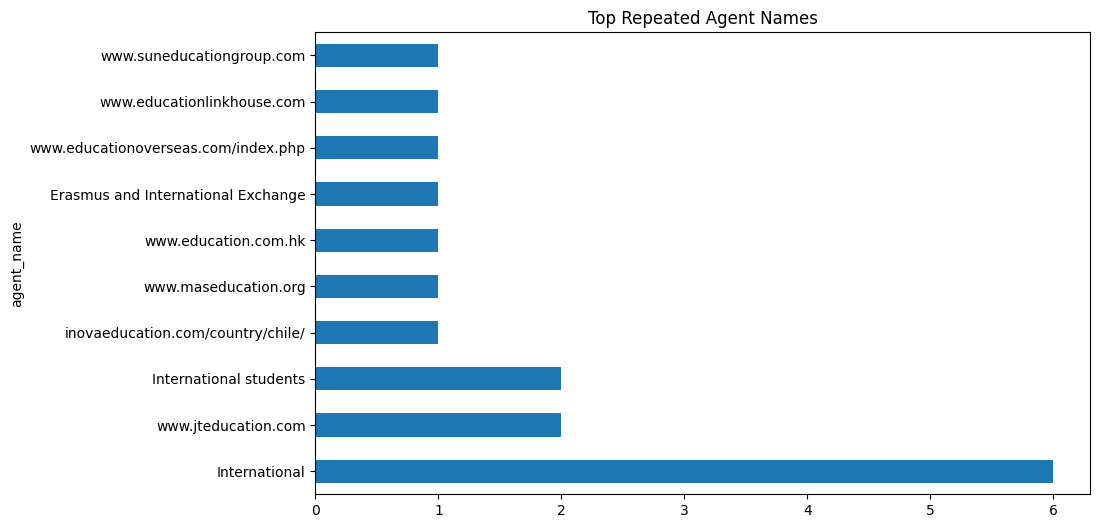

In [12]:
df["agent_name"].value_counts().head(10).plot(
    kind="barh",
    figsize=(10,6),
    title="Top Repeated Agent Names"
)

In [13]:
total_agents = len(df)
email_rate = df["has_email"].mean() * 100
phone_rate = df["has_phone"].mean() * 100

print("📊 DATASET SUMMARY")
print("-------------------")
print("Total Agents:", total_agents)
print("Email Coverage:", round(email_rate, 2), "%")
print("Phone Coverage:", round(phone_rate, 2), "%")
print("Unique Domains:", df["domain"].nunique())

📊 DATASET SUMMARY
-------------------
Total Agents: 62
Email Coverage: 33.87 %
Phone Coverage: 66.13 %
Unique Domains: 61


/tmp/ipykernel_1709/937278358.py:14: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


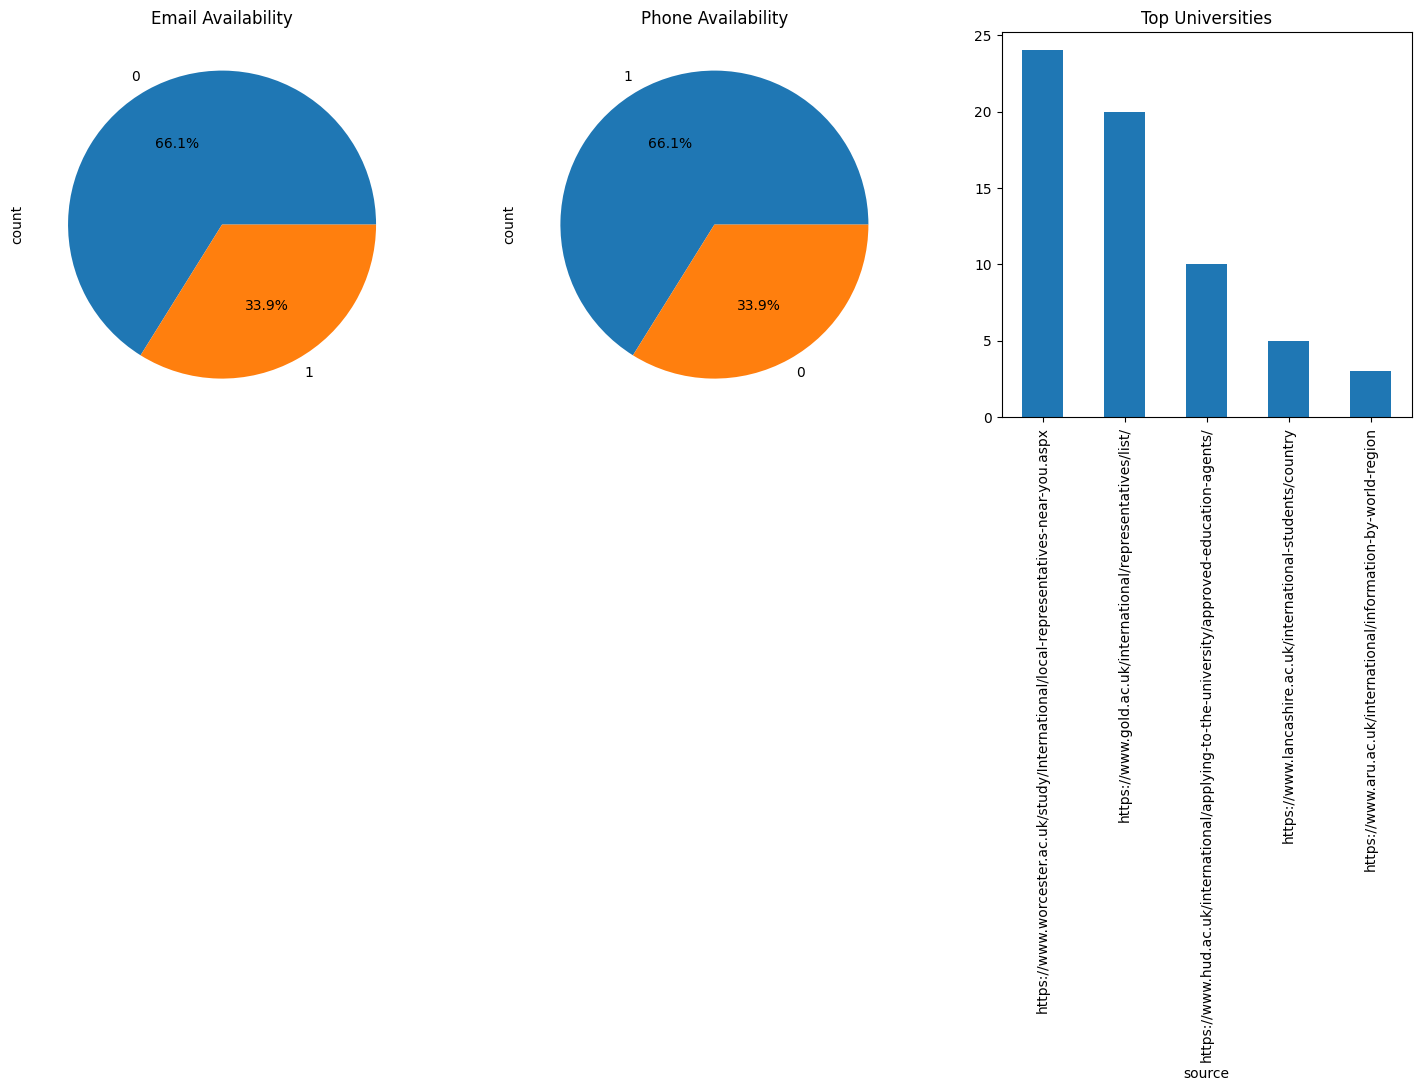

In [14]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 3, figsize=(18,5))

df["has_email"].value_counts().plot(kind="pie", ax=ax[0], autopct="%1.1f%%")
ax[0].set_title("Email Availability")

df["has_phone"].value_counts().plot(kind="pie", ax=ax[1], autopct="%1.1f%%")
ax[1].set_title("Phone Availability")

df["source"].value_counts().head(5).plot(kind="bar", ax=ax[2])
ax[2].set_title("Top Universities")

plt.tight_layout()
plt.show()